In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow import keras
from keras.optimizers import Adam, RMSprop
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, Conv2D, MaxPooling2D, GlobalAveragePooling2D, BatchNormalization
from keras.losses import sparse_categorical_crossentropy
from keras.datasets import fashion_mnist

In [31]:
fashion_dataset = fashion_mnist.load_data()

In [32]:
len(fashion_dataset)

2

In [33]:
fashion_train_data = fashion_dataset[0][0].reshape(-1, 28, 28, 1) / 255
fashion_train_labels = fashion_dataset[0][1]
print(f'Fashion train data shape: {fashion_train_data.shape}\nFashion train label shape: {fashion_train_labels.shape}')

Fashion train data shape: (60000, 28, 28, 1)
Fashion train label shape: (60000,)


In [34]:
fashion_test_data = fashion_dataset[1][0].reshape(-1, 28, 28, 1) / 255
fashion_test_labels = fashion_dataset[1][1]
print(f'Fashion test data shape: {fashion_test_data.shape}\nFashion test labels shape: {fashion_test_labels.shape}')

Fashion test data shape: (10000, 28, 28, 1)
Fashion test labels shape: (10000,)


In [35]:
X_train, X_val, y_train, y_val = train_test_split(fashion_train_data, fashion_train_labels, test_size= 0.25, random_state= 42)

In [36]:
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

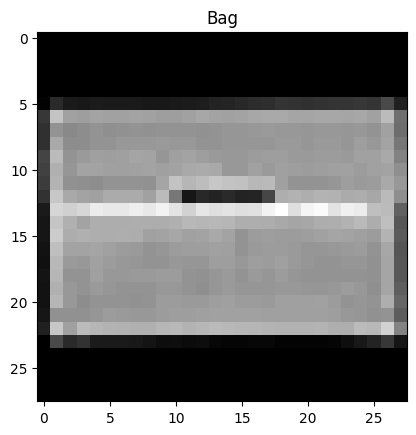

In [37]:
plt.imshow(X_train[5500], cmap= 'gray')
plt.title(class_names[y_train[5500]]);

In [38]:
def create_model():
    model = Sequential([
        Conv2D(32, (3, 3), padding= 'same', activation= 'relu'),
        BatchNormalization(),
        Conv2D(32, (3, 3), padding= 'same', activation= 'relu'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.15),
        Conv2D(64, (3, 3), padding= 'same', activation= 'relu'),
        BatchNormalization(),
        Conv2D(64, (3, 3), padding= 'same', activation= 'relu'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.2),
        Conv2D(128, (3, 3), padding= 'same', activation= 'relu'),
        BatchNormalization(),
        Conv2D(128, (3, 3), padding= 'same', activation= 'relu'),
        BatchNormalization(),
        GlobalAveragePooling2D(),
        Dense(128, activation= 'relu'),
        Dropout(0.2),
        Dense(10, activation= 'softmax')
    ])

    model.compile(optimizer= Adam(learning_rate= 0.001),
                loss= sparse_categorical_crossentropy,
                metrics= ['acc'])
    return model

## Epoch 10

In [39]:
model = create_model()
his = model.fit(X_train, y_train,
                batch_size= 64,epochs= 10,
                validation_data= (X_val, y_val),
                verbose= 2)

Epoch 1/10
704/704 - 24s - 34ms/step - acc: 0.8237 - loss: 0.4827 - val_acc: 0.8828 - val_loss: 0.3200
Epoch 2/10
704/704 - 6s - 8ms/step - acc: 0.8901 - loss: 0.3065 - val_acc: 0.9013 - val_loss: 0.2708
Epoch 3/10
704/704 - 6s - 9ms/step - acc: 0.9050 - loss: 0.2583 - val_acc: 0.9051 - val_loss: 0.2645
Epoch 4/10
704/704 - 6s - 8ms/step - acc: 0.9157 - loss: 0.2305 - val_acc: 0.9134 - val_loss: 0.2440
Epoch 5/10
704/704 - 6s - 9ms/step - acc: 0.9232 - loss: 0.2154 - val_acc: 0.9156 - val_loss: 0.2263
Epoch 6/10
704/704 - 6s - 8ms/step - acc: 0.9266 - loss: 0.2002 - val_acc: 0.9228 - val_loss: 0.2158
Epoch 7/10
704/704 - 6s - 9ms/step - acc: 0.9318 - loss: 0.1839 - val_acc: 0.9054 - val_loss: 0.2639
Epoch 8/10
704/704 - 10s - 14ms/step - acc: 0.9362 - loss: 0.1749 - val_acc: 0.9305 - val_loss: 0.1916
Epoch 9/10
704/704 - 6s - 9ms/step - acc: 0.9372 - loss: 0.1691 - val_acc: 0.9247 - val_loss: 0.2074
Epoch 10/10
704/704 - 6s - 8ms/step - acc: 0.9411 - loss: 0.1571 - val_acc: 0.9247 - va

In [40]:
test_loss, test_acc = model.evaluate(fashion_test_data, fashion_test_labels)
train_loss, train_acc = model.evaluate(X_train, y_train)
print(f'Test Accuracy: {test_acc * 100:.2f}\nTrain Accuracy: {train_acc * 100:.2f}\nTest Loss: {test_loss:.2f}\nTrain Loss: {train_loss:.2f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - acc: 0.9217 - loss: 0.2373
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.9488 - loss: 0.1412
Test Accuracy: 92.17
Train Accuracy: 94.88
Test Loss: 0.24
Train Loss: 0.14


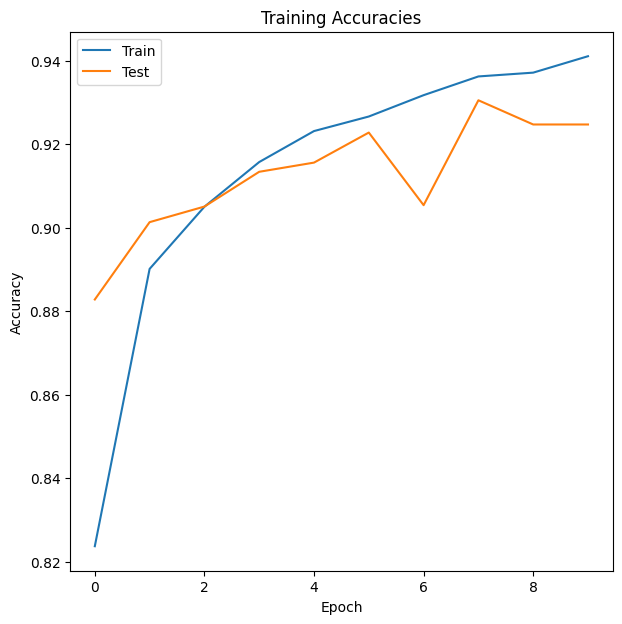

In [41]:
plt.figure(figsize= (7, 7))
plt.plot(his.history['acc'], label= 'Train')
plt.plot(his.history['val_acc'], label= 'Test')
plt.title('Training Accuracies')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

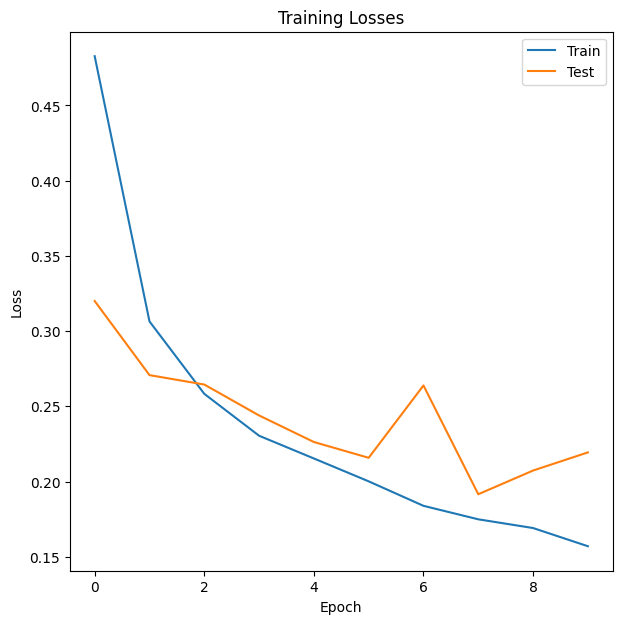

In [42]:
plt.figure(figsize= (7, 7))
plt.plot(his.history['loss'], label= 'Train')
plt.plot(his.history['val_loss'], label= 'Test')
plt.title('Training Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Epoch 15

In [43]:
model = create_model()
his = model.fit(X_train, y_train,
                batch_size= 64,epochs= 15,
                validation_data= (X_val, y_val),
                verbose= 2)

Epoch 1/15
704/704 - 24s - 34ms/step - acc: 0.8255 - loss: 0.4734 - val_acc: 0.7891 - val_loss: 0.6003
Epoch 2/15
704/704 - 6s - 8ms/step - acc: 0.8959 - loss: 0.2926 - val_acc: 0.8971 - val_loss: 0.2826
Epoch 3/15
704/704 - 6s - 9ms/step - acc: 0.9087 - loss: 0.2540 - val_acc: 0.9134 - val_loss: 0.2441
Epoch 4/15
704/704 - 6s - 8ms/step - acc: 0.9163 - loss: 0.2277 - val_acc: 0.8688 - val_loss: 0.3658
Epoch 5/15
704/704 - 10s - 15ms/step - acc: 0.9259 - loss: 0.2073 - val_acc: 0.9188 - val_loss: 0.2215
Epoch 6/15
704/704 - 6s - 9ms/step - acc: 0.9286 - loss: 0.1939 - val_acc: 0.9235 - val_loss: 0.2101
Epoch 7/15
704/704 - 6s - 8ms/step - acc: 0.9334 - loss: 0.1818 - val_acc: 0.9295 - val_loss: 0.1993
Epoch 8/15
704/704 - 6s - 9ms/step - acc: 0.9375 - loss: 0.1694 - val_acc: 0.9244 - val_loss: 0.2158
Epoch 9/15
704/704 - 6s - 8ms/step - acc: 0.9415 - loss: 0.1588 - val_acc: 0.9249 - val_loss: 0.2062
Epoch 10/15
704/704 - 6s - 9ms/step - acc: 0.9466 - loss: 0.1466 - val_acc: 0.9245 - va

In [44]:
test_loss, test_acc = model.evaluate(fashion_test_data, fashion_test_labels)
train_loss, train_acc = model.evaluate(X_train, y_train)
print(f'Test Accuracy: {test_acc * 100:.2f}\nTrain Accuracy: {train_acc * 100:.2f}\nTest Loss: {test_loss:.2f}\nTrain Loss: {train_loss:.2f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.9268 - loss: 0.2189
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.9692 - loss: 0.0833
Test Accuracy: 92.68
Train Accuracy: 96.92
Test Loss: 0.22
Train Loss: 0.08


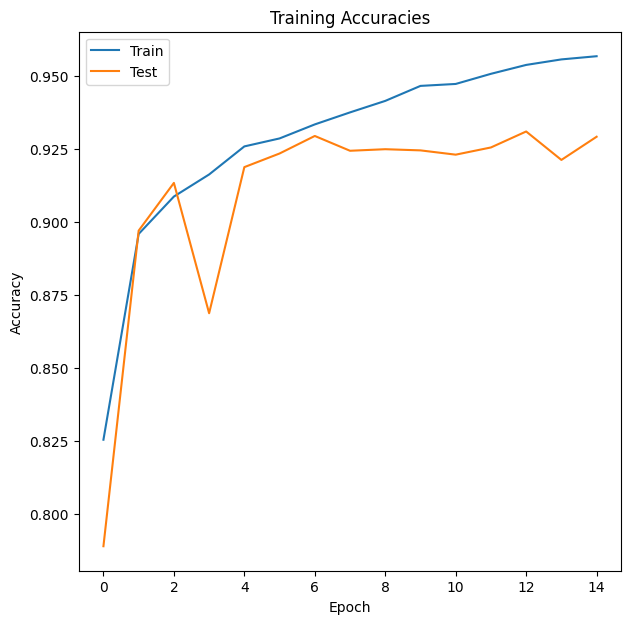

In [45]:
plt.figure(figsize= (7, 7))
plt.plot(his.history['acc'], label= 'Train')
plt.plot(his.history['val_acc'], label= 'Test')
plt.title('Training Accuracies')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

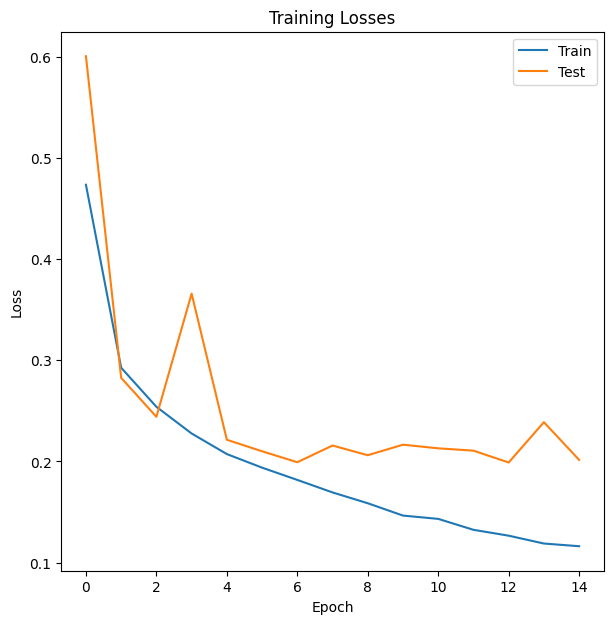

In [46]:
plt.figure(figsize= (7, 7))
plt.plot(his.history['loss'], label= 'Train')
plt.plot(his.history['val_loss'], label= 'Test')
plt.title('Training Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Epoch 20

In [47]:
model = create_model()
his = model.fit(X_train, y_train,
                batch_size= 64,epochs= 20,
                validation_data= (X_val, y_val),
                verbose= 2)

Epoch 1/20
704/704 - 23s - 33ms/step - acc: 0.8303 - loss: 0.4681 - val_acc: 0.8446 - val_loss: 0.4481
Epoch 2/20
704/704 - 6s - 8ms/step - acc: 0.8923 - loss: 0.2970 - val_acc: 0.9013 - val_loss: 0.2731
Epoch 3/20
704/704 - 6s - 9ms/step - acc: 0.9092 - loss: 0.2538 - val_acc: 0.8971 - val_loss: 0.2758
Epoch 4/20
704/704 - 6s - 8ms/step - acc: 0.9153 - loss: 0.2312 - val_acc: 0.9125 - val_loss: 0.2380
Epoch 5/20
704/704 - 6s - 9ms/step - acc: 0.9240 - loss: 0.2109 - val_acc: 0.9107 - val_loss: 0.2412
Epoch 6/20
704/704 - 6s - 8ms/step - acc: 0.9279 - loss: 0.1993 - val_acc: 0.9186 - val_loss: 0.2231
Epoch 7/20
704/704 - 6s - 9ms/step - acc: 0.9319 - loss: 0.1846 - val_acc: 0.9260 - val_loss: 0.2071
Epoch 8/20
704/704 - 6s - 8ms/step - acc: 0.9376 - loss: 0.1726 - val_acc: 0.9250 - val_loss: 0.2048
Epoch 9/20
704/704 - 6s - 8ms/step - acc: 0.9392 - loss: 0.1643 - val_acc: 0.9267 - val_loss: 0.2024
Epoch 10/20
704/704 - 6s - 8ms/step - acc: 0.9421 - loss: 0.1549 - val_acc: 0.9277 - val_

In [48]:
test_loss, test_acc = model.evaluate(fashion_test_data, fashion_test_labels)
train_loss, train_acc = model.evaluate(X_train, y_train)
print(f'Test Accuracy: {test_acc * 100:.2f}\nTrain Accuracy: {train_acc * 100:.2f}\nTest Loss: {test_loss:.2f}\nTrain Loss: {train_loss:.2f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.9297 - loss: 0.2263
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - acc: 0.9846 - loss: 0.0444
Test Accuracy: 92.97
Train Accuracy: 98.46
Test Loss: 0.23
Train Loss: 0.04


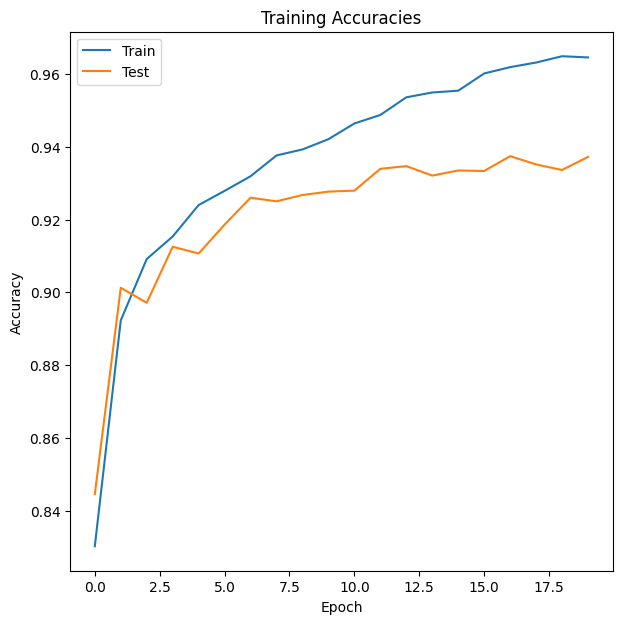

In [49]:
plt.figure(figsize= (7, 7))
plt.plot(his.history['acc'], label= 'Train')
plt.plot(his.history['val_acc'], label= 'Test')
plt.title('Training Accuracies')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

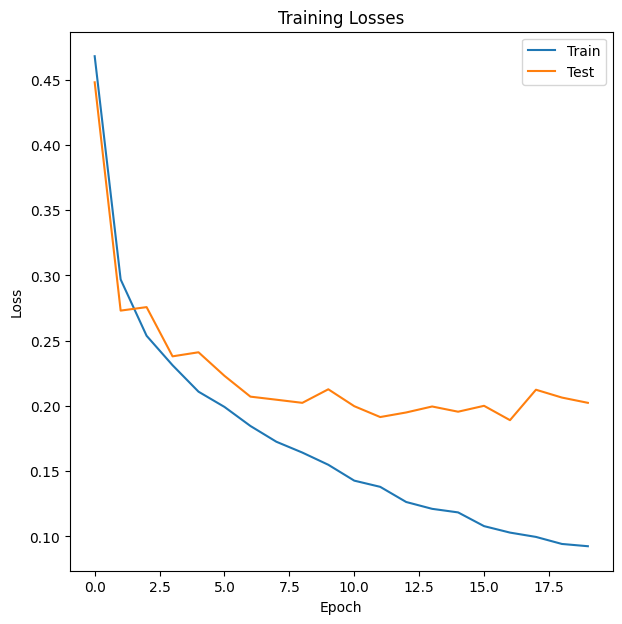

In [50]:
plt.figure(figsize= (7, 7))
plt.plot(his.history['loss'], label= 'Train')
plt.plot(his.history['val_loss'], label= 'Test')
plt.title('Training Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Epoch 25

In [52]:
model = create_model()
his = model.fit(X_train, y_train,
                batch_size= 64,epochs= 25,
                validation_data= (X_val, y_val),
                verbose= 2)

Epoch 1/25
704/704 - 24s - 34ms/step - acc: 0.8261 - loss: 0.4789 - val_acc: 0.8833 - val_loss: 0.3197
Epoch 2/25
704/704 - 6s - 9ms/step - acc: 0.8921 - loss: 0.2985 - val_acc: 0.8811 - val_loss: 0.3233
Epoch 3/25
704/704 - 6s - 9ms/step - acc: 0.9092 - loss: 0.2519 - val_acc: 0.9162 - val_loss: 0.2333
Epoch 4/25
704/704 - 6s - 9ms/step - acc: 0.9177 - loss: 0.2293 - val_acc: 0.9153 - val_loss: 0.2268
Epoch 5/25
704/704 - 6s - 9ms/step - acc: 0.9234 - loss: 0.2146 - val_acc: 0.9099 - val_loss: 0.2519
Epoch 6/25
704/704 - 10s - 15ms/step - acc: 0.9282 - loss: 0.1958 - val_acc: 0.9224 - val_loss: 0.2071
Epoch 7/25
704/704 - 6s - 8ms/step - acc: 0.9330 - loss: 0.1845 - val_acc: 0.9220 - val_loss: 0.2185
Epoch 8/25
704/704 - 6s - 9ms/step - acc: 0.9382 - loss: 0.1704 - val_acc: 0.9263 - val_loss: 0.2088
Epoch 9/25
704/704 - 6s - 8ms/step - acc: 0.9383 - loss: 0.1670 - val_acc: 0.9296 - val_loss: 0.1981
Epoch 10/25
704/704 - 6s - 9ms/step - acc: 0.9439 - loss: 0.1531 - val_acc: 0.9317 - va

In [53]:
test_loss, test_acc = model.evaluate(fashion_test_data, fashion_test_labels)
train_loss, train_acc = model.evaluate(X_train, y_train)
print(f'Test Accuracy: {test_acc * 100:.2f}\nTrain Accuracy: {train_acc * 100:.2f}\nTest Loss: {test_loss:.2f}\nTrain Loss: {train_loss:.2f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.9329 - loss: 0.2432
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.9900 - loss: 0.0312
Test Accuracy: 93.29
Train Accuracy: 99.00
Test Loss: 0.24
Train Loss: 0.03


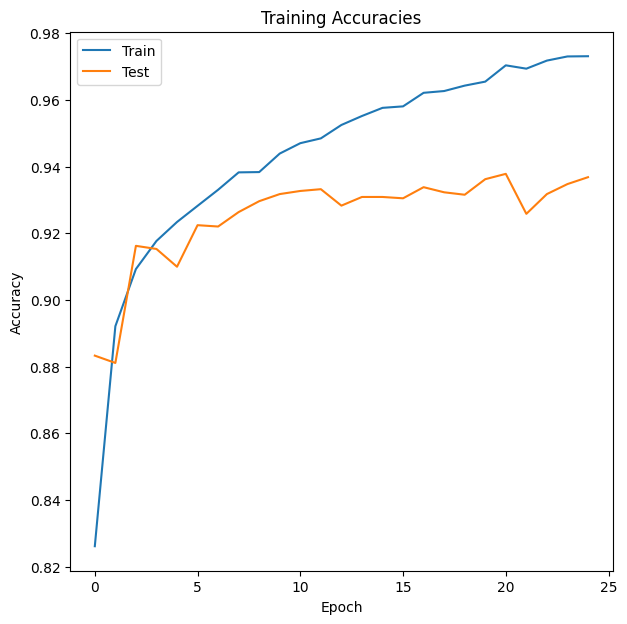

In [54]:
plt.figure(figsize= (7, 7))
plt.plot(his.history['acc'], label= 'Train')
plt.plot(his.history['val_acc'], label= 'Test')
plt.title('Training Accuracies')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

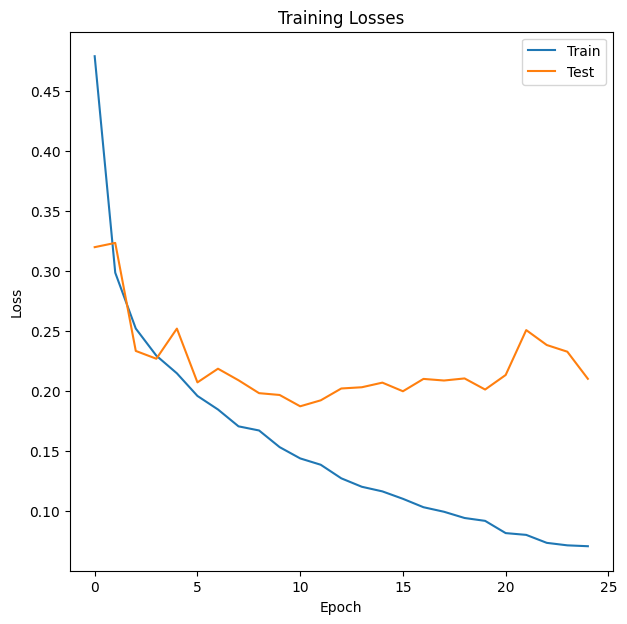

In [55]:
plt.figure(figsize= (7, 7))
plt.plot(his.history['loss'], label= 'Train')
plt.plot(his.history['val_loss'], label= 'Test')
plt.title('Training Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()